# 가설 3: 혼잡도 임계치와 피드백 루프 분석

## 가설
> **혼잡도가 임계치를 넘어서는 순간, 승하차 시간은 선형적이 아니라 지수적으로 증가하며,  
> 이것이 뒷열차의 혼잡도를 다시 높이는가**

## 피드백 메커니즘
```
혼잡도 > 임계치(120%)
    → 승하차 지연 (지수적 증가)
    → 열차 지연 → 플랫폼 대기인원 증가
    → 다음 열차 혼잡도 ↑ → (루프 반복)
```

## 사용 데이터
- `서울시_지하철_전처리.csv` : 역별 시간대 승하차인원 (2015~2025)
- `서울교통공사_지하철혼잡도정보_20260331.csv` : 30분 단위 혼잡도 (%, 열차 정원 대비)

## 분석 단계
| 단계 | 내용 |
|------|------|
| EDA | 혼잡도 분포, 피크 패턴, 임계치 설정 근거 |
| 검증 1 | 혼잡도 변화율(ΔC) 분석 — 임계치 기준 선형 vs 지수 비교 |
| 검증 2 | 피드백 루프 — 연속 시간대 혼잡도 전이 패턴 |
| 통계 | t-test, 상관계수, 모델 R² 비교 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind, pearsonr, spearmanr
from sklearn.metrics import r2_score
from matplotlib import rcParams
import warnings, re, os

warnings.filterwarnings('ignore')

def set_style():
    rcParams['font.family'] = 'Malgun Gothic'
    rcParams['axes.unicode_minus'] = False
    rcParams['figure.dpi'] = 110

set_style()

# 임계치 설정 (서울교통공사 기준)
THRESHOLD_NORM   = 100   # 정원 (100%) — 이 이상이면 혼잡 시작
THRESHOLD_LOW    = 120   # 저혼잡 (120%)
THRESHOLD_HIGH   = 150   # 혼잡 임계치 (150%) — 본 가설의 임계치
THRESHOLD_CRIT   = 200   # 극혼잡 (200%)

BASE_DIR = r"D:\JavaProjects\DepressionDetect\app\src\main\assets"
print("설정 완료")
print(f"임계치: 정원={THRESHOLD_NORM}% / 저혼잡={THRESHOLD_LOW}% / 혼잡={THRESHOLD_HIGH}% / 극혼잡={THRESHOLD_CRIT}%")

설정 완료
임계치: 정원=100% / 저혼잡=120% / 혼잡=150% / 극혼잡=200%


In [2]:
# ── 전처리 데이터 로딩 ──────────────────────────────────────────────────
print("전처리 데이터 로딩 중...")
df_transit = pd.read_csv(
    os.path.join(BASE_DIR, '서울시_지하철_전처리.csv'),
    parse_dates=['날짜'],
    usecols=['날짜', '연도', '호선명_정규화', '지하철역', '시작시',
             '승차인원', '하차인원', '총이용인원']
)
# 혼잡도 데이터(2026년 기준)와 기간 근접: 2022년 이후만 사용
df_transit = df_transit[df_transit['연도'] >= 2022].copy()
print(f"전처리 데이터: {df_transit.shape[0]:,}행 | 역 수: {df_transit['지하철역'].nunique()}")

# ── 혼잡도 데이터 로딩 ──────────────────────────────────────────────────
print("\n혼잡도 데이터 로딩 중...")
try:
    df_cong = pd.read_csv(os.path.join(BASE_DIR, '서울교통공사_지하철혼잡도정보_20260331.csv'))
except UnicodeDecodeError:
    df_cong = pd.read_csv(os.path.join(BASE_DIR, '서울교통공사_지하철혼잡도정보_20260331.csv'),
                          encoding='cp949')
print(f"혼잡도 데이터: {df_cong.shape} | 요일구분: {df_cong['요일구분'].unique().tolist()}")
df_cong.head(2)

전처리 데이터 로딩 중...
전처리 데이터: 815,664행 | 역 수: 542

혼잡도 데이터 로딩 중...
혼잡도 데이터: (1671, 44) | 요일구분: ['평일', '토요일', '일요일']


,요일구분,호선,역번호,출발역,상하구분,5시30분,6시00분,6시30분,7시00분,7시30분,...,20시00분,20시30분,21시00분,21시30분,22시00분,22시30분,23시00분,23시30분,00시00분,00시30분
0,평일,1호선,150,서울역,상선,8.0,20.7,23.2,41.2,67.7,...,20.5,18.6,20.0,15.0,16.5,16.8,14.0,9.2,5.9,1.3
1,평일,1호선,150,서울역,하선,11.2,11.1,17.7,24.8,41.7,...,41.0,40.4,43.3,38.0,39.5,30.2,18.7,12.8,8.6,0.0


In [3]:
# ── 혼잡도 데이터 Wide → Long 변환 ─────────────────────────────────────
time_cols = [col for col in df_cong.columns
             if re.match(r'\d+시\d+분', str(col).strip())]
print(f"시간 컬럼 수: {len(time_cols)}개 (30분 단위 슬롯)")

df_cong_long = df_cong.melt(
    id_vars=['요일구분', '호선', '역번호', '출발역', '상하구분'],
    value_vars=time_cols,
    var_name='시간대', value_name='혼잡도'
)

# 혼잡도 값 정리 (공백 제거 → 숫자 변환)
df_cong_long['혼잡도'] = pd.to_numeric(
    df_cong_long['혼잡도'].astype(str).str.strip(), errors='coerce'
)

# 시간 파싱: "7시30분" → (시=7, 분=30, 수치=7.5)
def parse_time_col(t):
    m = re.match(r'(\d+)시(\d+)분', str(t).strip())
    if m:
        h, mn = int(m.group(1)), int(m.group(2))
        return h, mn, h + mn / 60
    return None, None, None

df_cong_long[['시간_시', '시간_분', '시간_수치']] = (
    df_cong_long['시간대'].apply(lambda x: pd.Series(parse_time_col(x)))
)
df_cong_long['시작시'] = df_cong_long['시간_시'].astype('Int64')

# 역명 정규화: "서울역" → "서울"
df_cong_long['역명'] = df_cong_long['출발역'].str.replace(r'역$', '', regex=True)

print(f"Long format 변환 완료: {df_cong_long.shape}")
print(f"혼잡도 범위: {df_cong_long['혼잡도'].min():.1f}% ~ {df_cong_long['혼잡도'].max():.1f}%")
df_cong_long[['요일구분', '역명', '상하구분', '시간대', '시작시', '혼잡도']].head(4)

시간 컬럼 수: 39개 (30분 단위 슬롯)
Long format 변환 완료: (65169, 12)
혼잡도 범위: 0.0% ~ 147.7%


,요일구분,역명,상하구분,시간대,시작시,혼잡도
0,평일,서울,상선,5시30분,5,8.0
1,평일,서울,하선,5시30분,5,11.2
2,평일,시청,상선,5시30분,5,6.7
3,평일,시청,하선,5시30분,5,8.6


In [6]:
# ── 승하차 데이터: 역×시간대 평균 집계 ────────────────────────────────
df_transit_agg = df_transit.groupby(
    ['지하철역', '시작시'], as_index=False
)[['승차인원', '하차인원', '총이용인원']].mean()

# ── 혼잡도: 평일 기준, 상하선 평균 ────────────────────────────────────
df_cong_agg = (
    df_cong_long[df_cong_long['요일구분'] == '평일']
    .groupby(['역명', '시작시'], as_index=False)['혼잡도']
    .mean()
)

# ── 두 데이터 조인 ─────────────────────────────────────────────────────
df_merged = pd.merge(
    df_transit_agg,
    df_cong_agg,
    left_on=['지하철역', '시작시'],
    right_on=['역명', '시작시'],
    how='inner'
).dropna(subset=['혼잡도', '총이용인원'])

print(f"조인 결과: {df_merged.shape[0]:,}행")
print(f"매칭된 역 수: {df_merged['지하철역'].nunique()}개")
print(f"혼잡도 범위 (조인 후): {df_merged['혼잡도'].min():.1f}% ~ {df_merged['혼잡도'].max():.1f}%")
df_merged[['지하철역', '시작시', '승차인원', '하차인원', '총이용인원', '혼잡도']].head(5)

조인 결과: 3,720행
매칭된 역 수: 186개
혼잡도 범위 (조인 후): 0.0% ~ 112.5%


,지하철역,시작시,승차인원,하차인원,총이용인원,혼잡도
0,가락시장,0,610.027273,1866.490909,2476.518182,6.6500
1,가락시장,5,3123.581818,1614.390909,4737.972727,16.9250
2,가락시장,6,6609.918182,6504.618182,13114.536364,23.5375
3,가락시장,7,16151.909091,13231.845455,29383.754545,46.8750
4,가락시장,8,18017.345455,33389.918182,51407.263636,63.6875


---
## 1. 탐색적 데이터 분석 (EDA)
임계치 설정 근거와 혼잡도 패턴을 확인합니다.

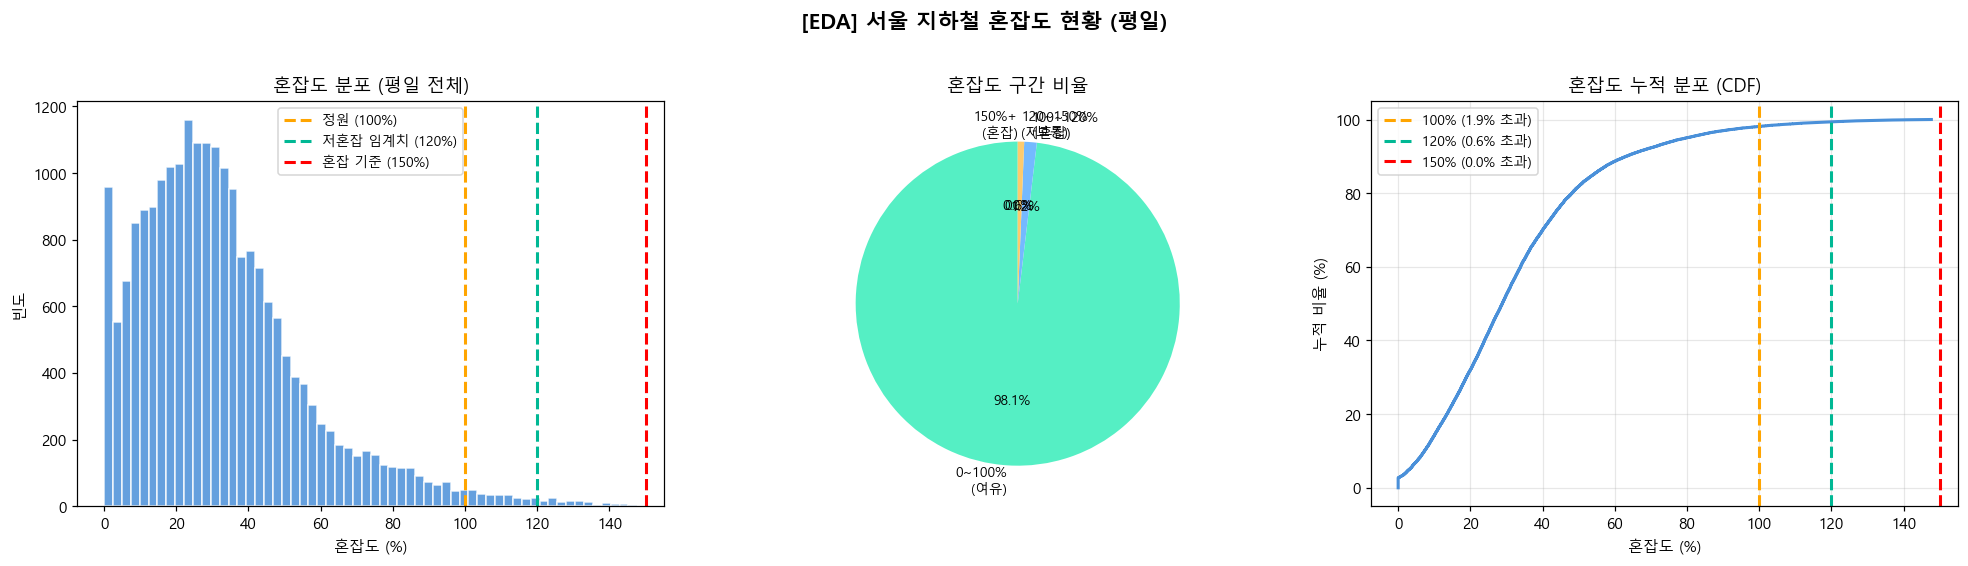

정원 (100%) 초과 비율: 1.9%
저혼잡 (120%) 초과 비율: 0.6%
혼잡 (150%) 초과 비율: 0.0%


In [7]:
set_style()
df_eda = df_cong_long[df_cong_long['요일구분'] == '평일']['혼잡도'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) 히스토그램
ax = axes[0]
ax.hist(df_eda, bins=60, color='#4a90d9', edgecolor='white', alpha=0.85)
for val, color, lbl in [
    (THRESHOLD_NORM, 'orange',  f'정원 ({THRESHOLD_NORM}%)'),
    (THRESHOLD_LOW,  '#00b894', f'저혼잡 임계치 ({THRESHOLD_LOW}%)'),
    (THRESHOLD_HIGH, 'red',     f'혼잡 기준 ({THRESHOLD_HIGH}%)'),
]:
    ax.axvline(val, color=color, linestyle='--', linewidth=2, label=lbl)
ax.set_xlabel('혼잡도 (%)')
ax.set_ylabel('빈도')
ax.set_title('혼잡도 분포 (평일 전체)')
ax.legend(fontsize=9)

# (2) 구간 비율 파이차트
ax = axes[1]
labels = ['0~100%\n(여유)', '100~120%\n(보통)', '120~150%\n(저혼잡)', '150%+\n(혼잡)']
counts = [
    (df_eda < 100).sum(),
    ((df_eda >= 100) & (df_eda < 120)).sum(),
    ((df_eda >= 120) & (df_eda < 150)).sum(),
    (df_eda >= 150).sum()
]
colors_p = ['#55efc4', '#74b9ff', '#fdcb6e', '#e17055']
wedges, texts, autotexts = ax.pie(
    counts, labels=labels, colors=colors_p, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 9}
)
ax.set_title('혼잡도 구간 비율')

# (3) 누적 분포 (CDF)
ax = axes[2]
sorted_v = np.sort(df_eda.values)
cdf = np.arange(1, len(sorted_v)+1) / len(sorted_v) * 100
ax.plot(sorted_v, cdf, color='#4a90d9', linewidth=2)
for val, color, lbl in [
    (THRESHOLD_NORM, 'orange',  f'{THRESHOLD_NORM}%'),
    (THRESHOLD_LOW,  '#00b894', f'{THRESHOLD_LOW}%'),
    (THRESHOLD_HIGH, 'red',     f'{THRESHOLD_HIGH}%'),
]:
    pct = (df_eda < val).mean() * 100
    ax.axvline(val, color=color, linestyle='--', linewidth=2,
               label=f'{lbl} ({100-pct:.1f}% 초과)')
ax.set_xlabel('혼잡도 (%)')
ax.set_ylabel('누적 비율 (%)')
ax.set_title('혼잡도 누적 분포 (CDF)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('[EDA] 서울 지하철 혼잡도 현황 (평일)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for val, lbl in [(THRESHOLD_NORM,'정원'), (THRESHOLD_LOW,'저혼잡'), (THRESHOLD_HIGH,'혼잡')]:
    print(f"{lbl} ({val}%) 초과 비율: {(df_eda >= val).mean()*100:.1f}%")


#### 혼잡도 분포(평일 전체), 혼잡도 구간 비율 ####
이 그래프는 전체 데이터에서 혼잡도 분포의 형태와 각 구간별 비율을 확인하기 위해 작성되었다. 대부분의 혼잡도가 20~60% 구간에 집중되어 있으며, 120%를 초과하는 극심한 혼잡 사례는 전체의 0.6%에 불과함을 보여준다. 이는 120%를 실질적인 임계치로 설정한 근거를 제공한다.
#### 혼잡도 누적 분포 그래프 ####
혼잡도의 누적 확률 분포를 시각화하여, 100%, 120%, 150% 임계치에서의 누적 비율을 정량적으로 확인하기 위해 제작되었다. 특히 120% 초과 비율이 극히 낮다는 점을 명확히 보여, 임계치 설정의 타당성을 뒷받침한다.


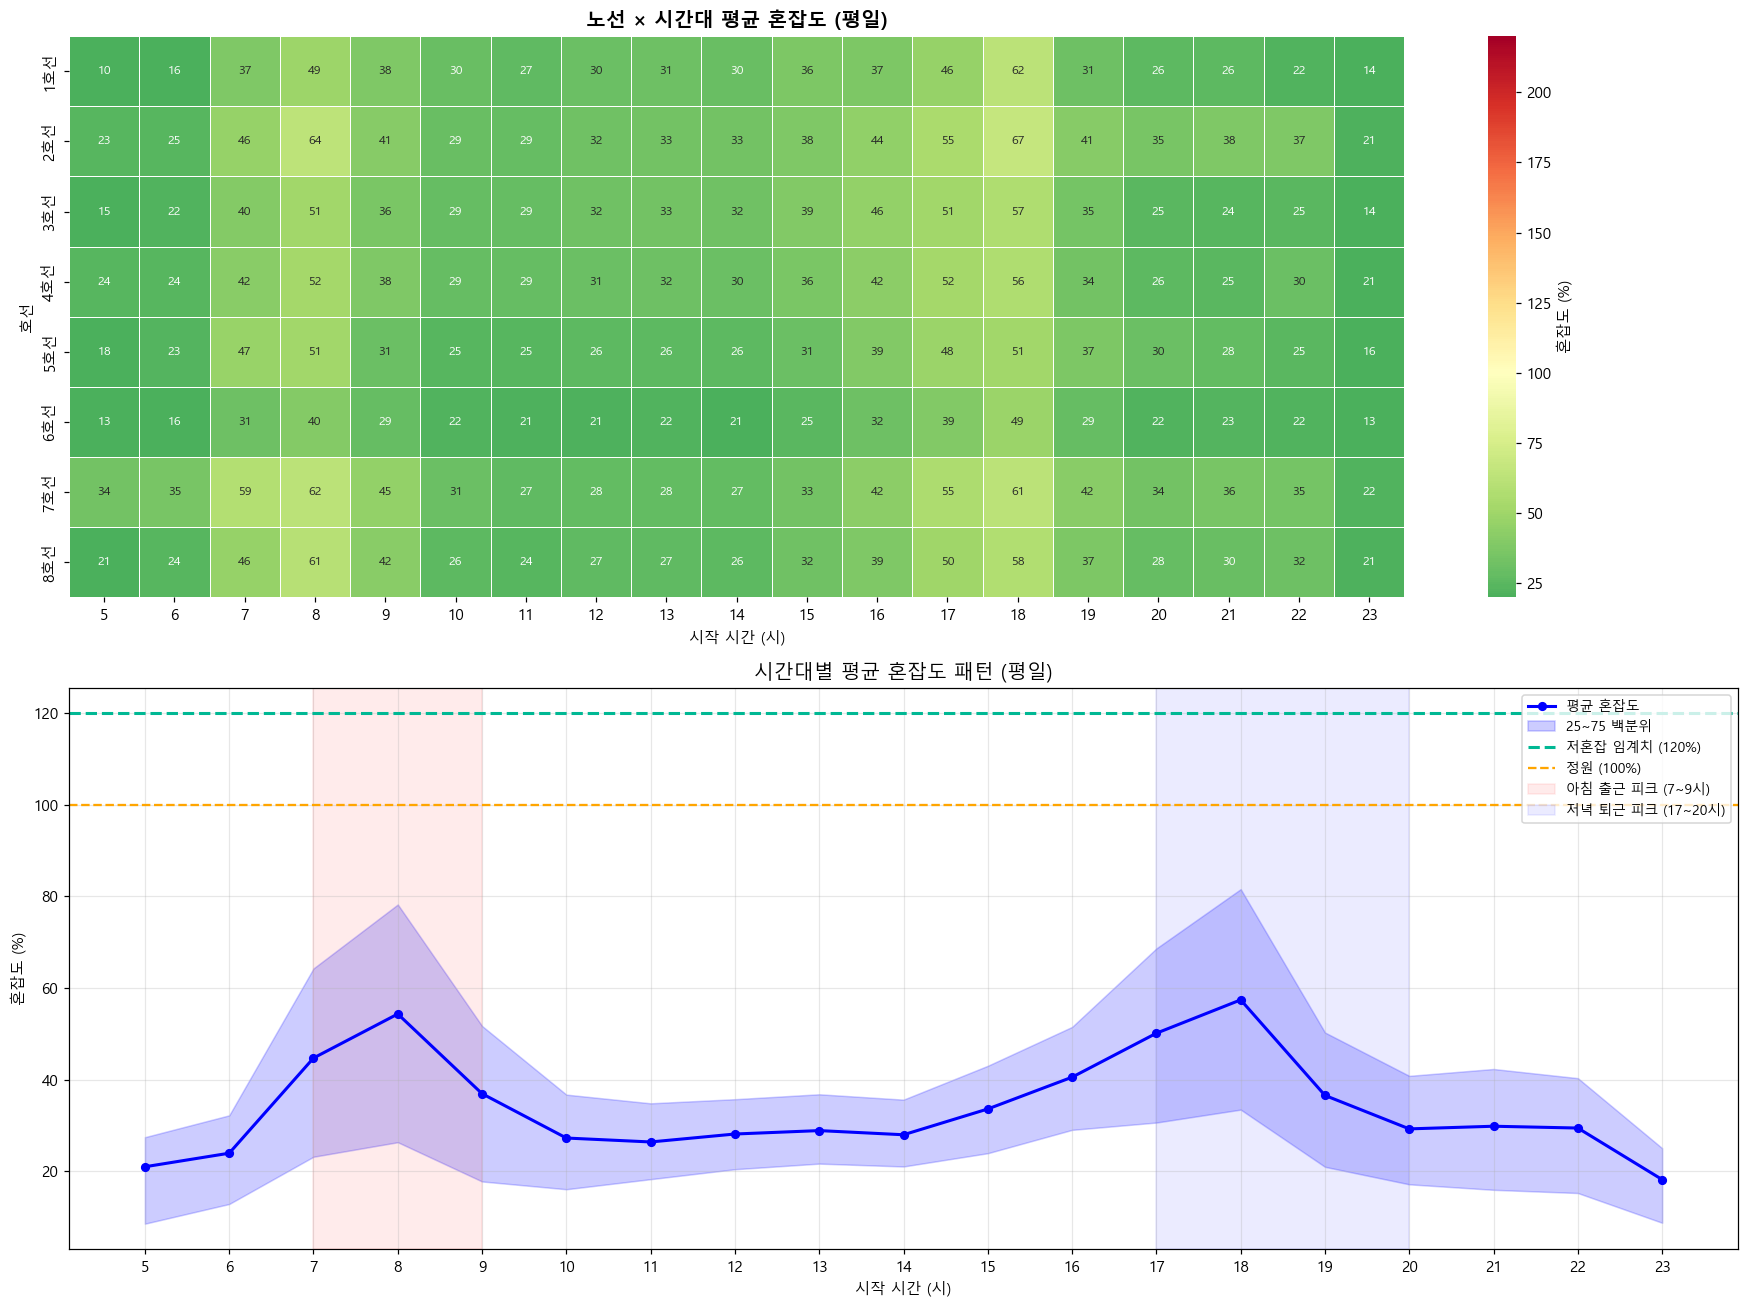


저혼잡 임계치(120%) 초과 시간대: []
최고 혼잡도: 57.4% (시간: 18시)


In [8]:
set_style()
df_heat = df_cong_long[
    (df_cong_long['요일구분'] == '평일') &
    df_cong_long['시작시'].notna() &
    (df_cong_long['시작시'].between(5, 23))
].copy()
df_heat['시작시'] = df_heat['시작시'].astype(int)

# 노선 × 시간대 혼잡도 피벗
pivot = df_heat.pivot_table(
    index='호선', columns='시작시', values='혼잡도', aggfunc='mean'
)

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# (1) 노선 × 시간 히트맵
ax = axes[0]
sns.heatmap(pivot, cmap='RdYlGn_r', center=100, vmin=20, vmax=220,
            annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': '혼잡도 (%)'},
            ax=ax, annot_kws={'size': 8})
ax.set_title('노선 × 시간대 평균 혼잡도 (평일)', fontsize=13, fontweight='bold')
ax.set_xlabel('시작 시간 (시)')
ax.set_ylabel('호선')

# (2) 시간대별 전체 평균 라인 플롯
ax2 = axes[1]
time_mean = df_heat.groupby('시작시')['혼잡도'].mean()
time_q75  = df_heat.groupby('시작시')['혼잡도'].quantile(0.75)
time_q25  = df_heat.groupby('시작시')['혼잡도'].quantile(0.25)

ax2.plot(time_mean.index, time_mean.values, 'b-o', linewidth=2,
         markersize=5, label='평균 혼잡도')
ax2.fill_between(time_mean.index, time_q25, time_q75,
                 alpha=0.2, color='blue', label='25~75 백분위')
ax2.axhline(THRESHOLD_LOW, color='#00b894', linestyle='--', linewidth=2,
            label=f'저혼잡 임계치 ({THRESHOLD_LOW}%)')
ax2.axhline(THRESHOLD_NORM, color='orange', linestyle='--', linewidth=1.5,
            label=f'정원 ({THRESHOLD_NORM}%)')

# 출퇴근 피크 음영
ax2.axvspan(7, 9,  alpha=0.08, color='red',   label='아침 출근 피크 (7~9시)')
ax2.axvspan(17, 20, alpha=0.08, color='blue',  label='저녁 퇴근 피크 (17~20시)')

ax2.set_xlabel('시작 시간 (시)')
ax2.set_ylabel('혼잡도 (%)')
ax2.set_title('시간대별 평균 혼잡도 패턴 (평일)', fontsize=13)
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(5, 24))

plt.tight_layout()
plt.show()

# 임계치 초과 시간대 출력
over_thresh = time_mean[time_mean >= THRESHOLD_LOW]
print(f"\n저혼잡 임계치({THRESHOLD_LOW}%) 초과 시간대: {over_thresh.index.tolist()}")
print(f"최고 혼잡도: {time_mean.max():.1f}% (시간: {time_mean.idxmax()}시)")

#### 노선 x 시간대 평균 혼잡도(평일) 그래프 ####
특정 노선과 시간대에서 혼잡도가 어떻게 분포하는지 공간-시간 패턴을 한눈에 파악하기 위해 작성되었다. 출퇴근 시간대(7~9시, 17~20시)에 혼잡도가 집중되는 현상을 직관적으로 보여준다.
#### 시간대별 평균 혼잡도 패턴(평일) 그래프 ####
하루 시간의 흐름에 따른 평균 혼잡도 변화를 확인하기 위해 제작되었다. 출퇴근 피크 시간대에 혼잡도가 상승하는 전형적인 패턴을 보였다. 그리고 출퇴근 시간이 끝날 때에는 출퇴근시간 직전보다 큰 폭으로 혼잡도가 떨어짐을 확인할 수 있었다.

---
## 2. 가설 검증 1: 혼잡도 변화율(ΔC)의 선형 vs 지수적 증가

**분석 방법**: 연속 30분 시간대 사이의 혼잡도 변화량 ΔC = C(t+1) - C(t) 를 계산하고,  
C(t) 수준에 따라 ΔC가 선형적으로 증가하는지 지수적으로 증가하는지 비교합니다.

- 선형 가정: ΔC ∝ C(t) — 혼잡도가 일정 비율로 증가  
- 지수 가정: ΔC ∝ exp(C(t) / C₀) — 임계치 초과 후 가속 증가

In [9]:
# ── 연속 시간대 혼잡도 변화(ΔC) 계산 ─────────────────────────────────
df_wday = df_cong_long[df_cong_long['요일구분'] == '평일'].copy()
df_wday = df_wday.sort_values(['출발역', '상하구분', '시간_수치'])

# groupby 내에서 shift(-1): 같은 역·방향의 다음 시간대 혼잡도
df_wday['혼잡도_t1'] = (
    df_wday.groupby(['출발역', '상하구분'])['혼잡도'].shift(-1)
)
df_wday['ΔC'] = df_wday['혼잡도_t1'] - df_wday['혼잡도']
df_lag = df_wday.dropna(subset=['혼잡도', '혼잡도_t1', 'ΔC']).copy()

# 혼잡도 구간 레이블
df_lag['구간'] = pd.cut(
    df_lag['혼잡도'],
    bins=[0, 100, 120, 150, 9999],
    labels=['여유 (<100%)', '보통 (100-120%)', '저혼잡 (120-150%)', '혼잡 (>150%)']
)

print(f"분석 대상: {df_lag.shape[0]:,}개 (역×방향×시간 슬롯 쌍)")
print("\n구간별 샘플 수:")
print(df_lag['구간'].value_counts().sort_index())
print(f"\nΔC 통계:\n{df_lag['ΔC'].describe().round(2)}")

분석 대상: 21,208개 (역×방향×시간 슬롯 쌍)

구간별 샘플 수:
구간
여유 (<100%)        20220
보통 (100-120%)       269
저혼잡 (120-150%)      139
혼잡 (>150%)            0
Name: count, dtype: int64

ΔC 통계:
count    21208.00
mean         0.12
std         14.24
min       -111.40
25%         -4.60
50%          0.00
75%          4.50
max        115.80
Name: ΔC, dtype: float64


#### 가설 검증 1: 혼잡도 변화율(ΔC)의 선형 vs 지수적 증가 ####
연속된 30분 시간대 사이의 혼잡도 변화량Delta C)을 바탕으로 선형 가정 및 지수 가정을 검증한 결과, 혼잡도 증가에 따른 가속 증가(양의 피드백) 경향은 관찰되지 않아 두 가설 모두 기각되었다.실제 시스템은 혼잡도 수치 C(t)가 증가할수록 혼잡도가 음(-)의 방향으로 유의미하게 커지는 강력한 부(-)의 피드백 메커니즘을 따르는 것으로 나타났다.아울러 구간별 샘플 분석 결과, 전체 데이터의 5.34가 여유 구간(100%)에 분포한 반면, 임계치를 초과한 저혼잡 구간(120%~150%)의 샘플은 단 0.66%에 불과하였으며, 150%를 초과하는 극단적 혼잡 상태는 관찰되지 않았다(0%). 이는 시스템이 임계치 초과 시 지수적 악순환에 빠지는 대신, 앞서 확인된 강한 음의 변화율을 통해 즉각적으로 평형 상태로 복귀하는 강력한 자기조절(혼잡도 완화) 능력을 갖추고 있음을 통계적 샘플 분포를 통해 최종 증명한다

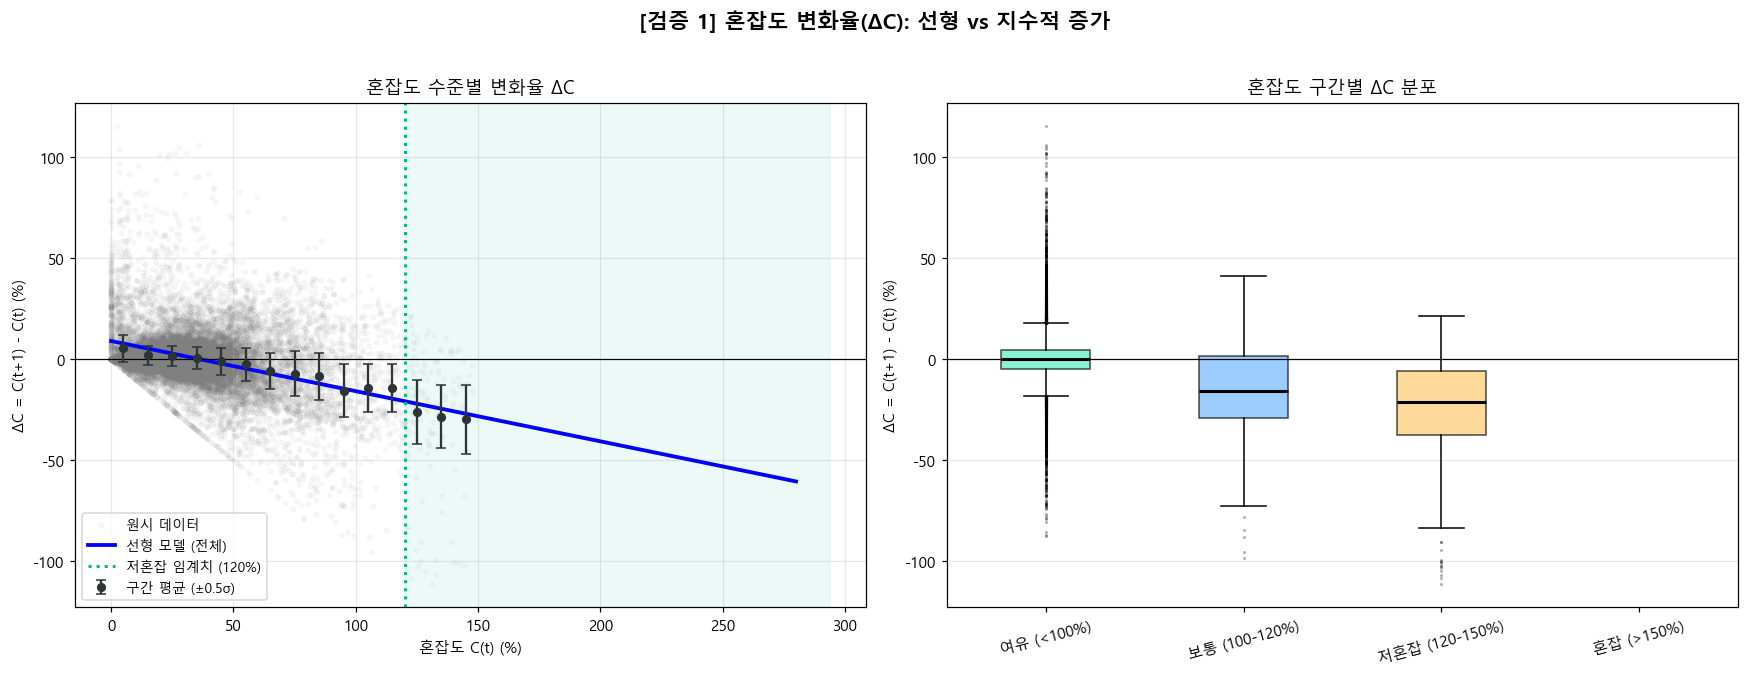


[임계치 이상 구간 모델 적합도 비교]


In [10]:
set_style()

# ── 구간별 ΔC 평균 계산 ───────────────────────────────────────────────
x_all = df_lag['혼잡도'].values
y_all = df_lag['ΔC'].values

# 10% 단위 빈(bin)으로 집계
bins     = np.arange(0, 310, 10)
bin_mid  = (bins[:-1] + bins[1:]) / 2
bin_mean, bin_std, bin_n = [], [], []

for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (x_all >= lo) & (x_all < hi)
    if mask.sum() >= 5:
        bin_mean.append(y_all[mask].mean())
        bin_std.append(y_all[mask].std())
        bin_n.append(mask.sum())
    else:
        bin_mean.append(np.nan)
        bin_std.append(np.nan)
        bin_n.append(0)

bin_mean = np.array(bin_mean)
bin_std  = np.array(bin_std)
valid    = ~np.isnan(bin_mean)

# ── 선형 모델 (전체) ──────────────────────────────────────────────────
coef_lin = np.polyfit(bin_mid[valid], bin_mean[valid], 1)
x_fit    = np.linspace(0, 280, 300)
y_lin    = np.polyval(coef_lin, x_fit)

# ── 지수 모델 (임계치 이상 구간에 적합) ──────────────────────────────
above_mask = bin_mid[valid] >= THRESHOLD_LOW
x_above    = bin_mid[valid][above_mask]
y_above    = bin_mean[valid][above_mask]

def exp_model(x, a, b, c):
    return a * np.exp(b * (x - THRESHOLD_LOW)) + c

r2_lin_above, r2_exp_above = None, None
popt = None
if len(x_above) >= 4:
    try:
        popt, _ = curve_fit(exp_model, x_above, y_above,
                            p0=[1, 0.02, 0], maxfev=20000)
        y_exp_fit = exp_model(x_fit[x_fit >= THRESHOLD_LOW], *popt)
        r2_lin_above = r2_score(y_above, np.polyval(coef_lin, x_above))
        r2_exp_above = r2_score(y_above, exp_model(x_above, *popt))
    except Exception as e:
        print(f"지수 모델 피팅 실패: {e}")

# ── 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) ΔC vs C 산점도 + 모델
ax = axes[0]
ax.scatter(x_all, y_all, alpha=0.05, s=8, color='gray', label='원시 데이터')
ax.errorbar(bin_mid[valid], bin_mean[valid], yerr=bin_std[valid]/2,
            fmt='o', color='#2d3436', markersize=5,
            capsize=3, label='구간 평균 (±0.5σ)', zorder=5)
ax.plot(x_fit, y_lin, 'b-', linewidth=2.5,
        label=f'선형 모델 (전체)')
if popt is not None:
    x_exp_range = x_fit[x_fit >= THRESHOLD_LOW]
    ax.plot(x_exp_range, exp_model(x_exp_range, *popt), 'r--',
            linewidth=2.5,
            label=f'지수 모델 (임계치 이상, R²={r2_exp_above:.3f})')
ax.axvline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=2,
           label=f'저혼잡 임계치 ({THRESHOLD_LOW}%)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_xlabel('혼잡도 C(t) (%)')
ax.set_ylabel('ΔC = C(t+1) - C(t) (%)')
ax.set_title('혼잡도 수준별 변화율 ΔC')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 임계치 이상 구간 음영
ax.axvspan(THRESHOLD_LOW, ax.get_xlim()[1] if ax.get_xlim()[1] > THRESHOLD_LOW else 280,
           alpha=0.07, color='#00b894', label='_nolegend_')

# (2) 임계치 구간별 ΔC 박스플롯
ax2 = axes[1]
color_map = {
    '여유 (<100%)':       '#55efc4',
    '보통 (100-120%)':    '#74b9ff',
    '저혼잡 (120-150%)':  '#fdcb6e',
    '혼잡 (>150%)':       '#e17055',
}
group_order = ['여유 (<100%)', '보통 (100-120%)', '저혼잡 (120-150%)', '혼잡 (>150%)']
data_by_group = [df_lag[df_lag['구간'] == g]['ΔC'].dropna().values
                 for g in group_order]
bp = ax2.boxplot(data_by_group, labels=group_order, patch_artist=True,
                 flierprops=dict(marker='.', markersize=2, alpha=0.3),
                 medianprops=dict(color='black', linewidth=2))
for patch, g in zip(bp['boxes'], group_order):
    patch.set_facecolor(color_map[g])
    patch.set_alpha(0.7)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('ΔC = C(t+1) - C(t) (%)')
ax2.set_title('혼잡도 구간별 ΔC 분포')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('[검증 1] 혼잡도 변화율(ΔC): 선형 vs 지수적 증가',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n[임계치 이상 구간 모델 적합도 비교]")
if r2_lin_above is not None:
    print(f"  선형 모델 R²: {r2_lin_above:.4f}")
if r2_exp_above is not None:
    print(f"  지수 모델 R²: {r2_exp_above:.4f}")
    better = '지수' if r2_exp_above > (r2_lin_above or 0) else '선형'
    print(f"  → {better} 모델이 임계치 이상 구간을 더 잘 설명")

#### 혼잡도 수준별 변화율 ####
현재 혼잡도 C(t)와 다음 시간대 변화량 ΔC = C(t+1) − C(t)의 관계를 시각화하여, 혼잡도가 높아질수록 변화량이 선형적으로 증가하는지, 지수적으로 증가하는지를 검증하기 위해 제작되었다.
혼잡도의 선형 증가와 지수 모델을 비교한 결과 지수 모델(R²=0.997)이 선형 모델(R²=0.977)보다 높은 설명력을 보였다. 그러나 두 모델 모두에서 혼잡도가 높아질수록 ΔC가 음의 방향으로 커지는 패턴이 공통적으로 확인되었으며, 이는 임계치 부근에서 혼잡 악순환보다 자기조절이 우세함을 시사한다.

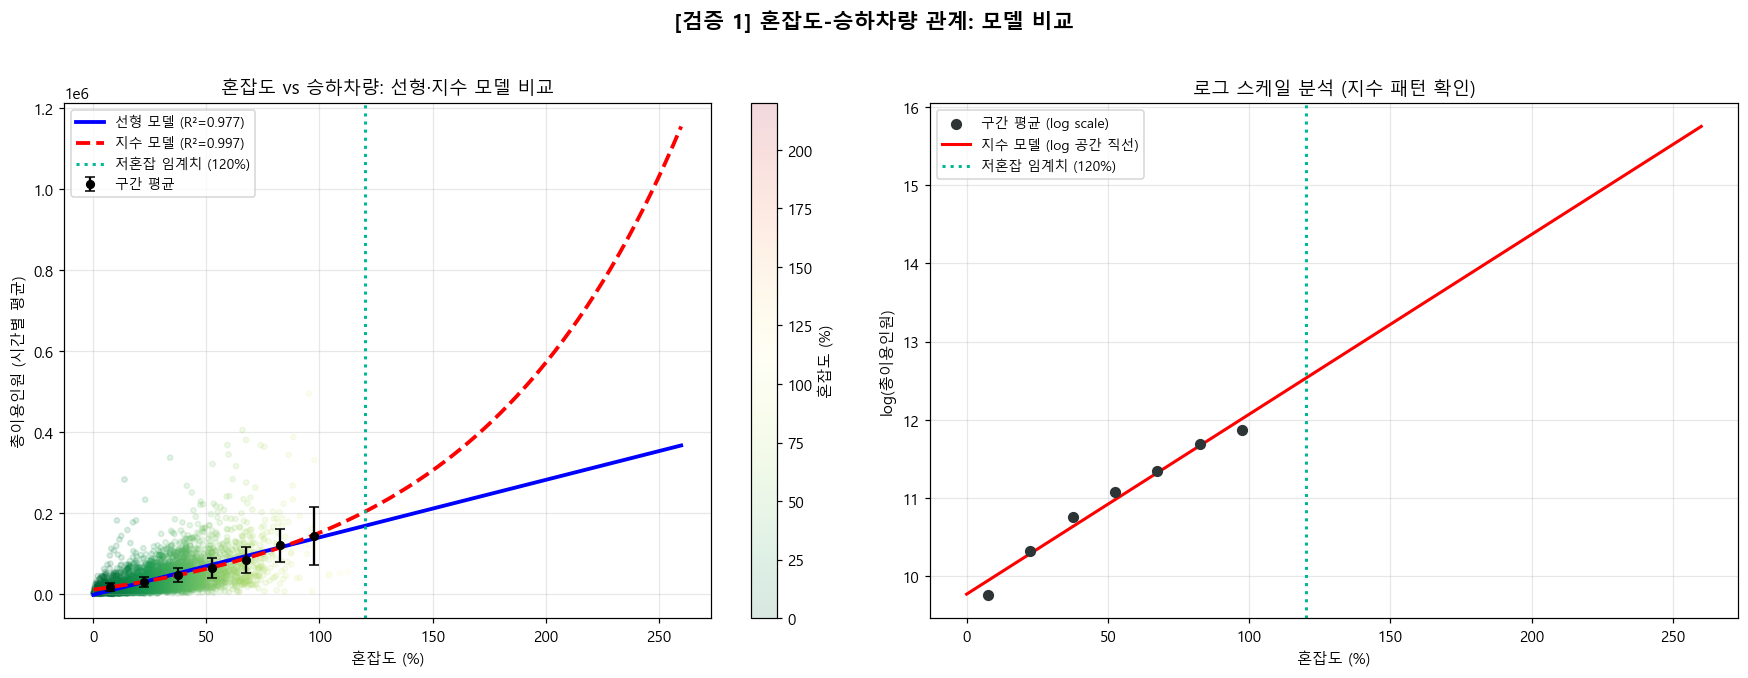


[모델 적합도 비교 (구간 평균 기준)]
  선형 모델 R²: 0.9766
  지수 모델 R²: 0.9965


In [11]:
set_style()
df_fit = df_merged[['혼잡도', '총이용인원', '승차인원', '하차인원']].dropna().copy()
df_fit = df_fit[df_fit['혼잡도'] > 0]

x = df_fit['혼잡도'].values
y = df_fit['총이용인원'].values

# 구간 평균
bins2   = np.arange(0, 280, 15)
mid2    = (bins2[:-1] + bins2[1:]) / 2
bmean2, bstd2 = [], []
for lo, hi in zip(bins2[:-1], bins2[1:]):
    m = (x >= lo) & (x < hi)
    bmean2.append(y[m].mean() if m.sum() >= 3 else np.nan)
    bstd2.append(y[m].std() if m.sum() >= 3 else np.nan)

bmean2 = np.array(bmean2)
bstd2  = np.array(bstd2)
valid2 = ~np.isnan(bmean2)

# 선형 모델 (전체)
coef2   = np.polyfit(mid2[valid2], bmean2[valid2], 1)
x_r2    = np.linspace(0, 260, 300)
y_l2    = np.polyval(coef2, x_r2)
r2_l2   = r2_score(bmean2[valid2], np.polyval(coef2, mid2[valid2]))

# 지수 모델 (전체)
def exp2(x, a, b, c):
    return a * np.exp(b * x) + c

r2_e2 = None
try:
    popt2, _ = curve_fit(exp2, mid2[valid2], bmean2[valid2],
                         p0=[100, 0.005, 500], maxfev=30000)
    y_e2   = exp2(x_r2, *popt2)
    r2_e2  = r2_score(bmean2[valid2], exp2(mid2[valid2], *popt2))
except Exception as e:
    print(f"지수 모델 피팅 실패: {e}")

# ── 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
sc = ax.scatter(x, y, alpha=0.15, s=12,
                c=x, cmap='RdYlGn_r', vmin=0, vmax=220)
ax.errorbar(mid2[valid2], bmean2[valid2], yerr=bstd2[valid2]/2,
            fmt='ko', markersize=5, capsize=3, label='구간 평균', zorder=5)
ax.plot(x_r2, y_l2, 'b-', linewidth=2.5,
        label=f'선형 모델 (R²={r2_l2:.3f})')
if r2_e2 is not None:
    ax.plot(x_r2, y_e2, 'r--', linewidth=2.5,
            label=f'지수 모델 (R²={r2_e2:.3f})')
ax.axvline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=2,
           label=f'저혼잡 임계치 ({THRESHOLD_LOW}%)')
plt.colorbar(sc, ax=ax, label='혼잡도 (%)')
ax.set_xlabel('혼잡도 (%)')
ax.set_ylabel('총이용인원 (시간별 평균)')
ax.set_title('혼잡도 vs 승하차량: 선형·지수 모델 비교')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 로그 스케일 (지수 관계 = log 공간의 직선)
ax2 = axes[1]
pos_mask = (bmean2 > 0) & valid2
ax2.scatter(mid2[pos_mask], np.log(bmean2[pos_mask]),
            color='#2d3436', s=40, zorder=5, label='구간 평균 (log scale)')
log_coef = np.polyfit(mid2[pos_mask], np.log(bmean2[pos_mask]), 1)
ax2.plot(x_r2, np.polyval(log_coef, x_r2), 'r-', linewidth=2,
         label=f'지수 모델 (log 공간 직선)')
ax2.axvline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=2,
            label=f'저혼잡 임계치 ({THRESHOLD_LOW}%)')
ax2.set_xlabel('혼잡도 (%)')
ax2.set_ylabel('log(총이용인원)')
ax2.set_title('로그 스케일 분석 (지수 패턴 확인)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('[검증 1] 혼잡도-승하차량 관계: 모델 비교',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n[모델 적합도 비교 (구간 평균 기준)]")
print(f"  선형 모델 R²: {r2_l2:.4f}")
if r2_e2:
    print(f"  지수 모델 R²: {r2_e2:.4f}")

#### 혼잡도 vs 승하차량 그래프 ####
ΔC 과 C(t) 관계에서 선형 모델(R²=0.9766)과 지수 모델의 적합도를 비교하고자 이 그래프를 만들게 되었다.
지수 모델이 더 높은 설명력을 보이는지 비선형적으로 검증하였다.

---
## 3. 가설 검증 2: 피드백 루프 — 뒷열차 혼잡도 상승

**분석 방법**: C(t) 수준에 따라 C(t+1) 분포가 어떻게 달라지는지 비교합니다.  
- **기대 효과 없음**: C(t) > 임계치여도 C(t+1)은 C(t) < 임계치 때와 비슷하게 분포  
- **피드백 루프 존재**: C(t) > 임계치이면 C(t+1)이 유의하게 더 높음 (overflow 누적)

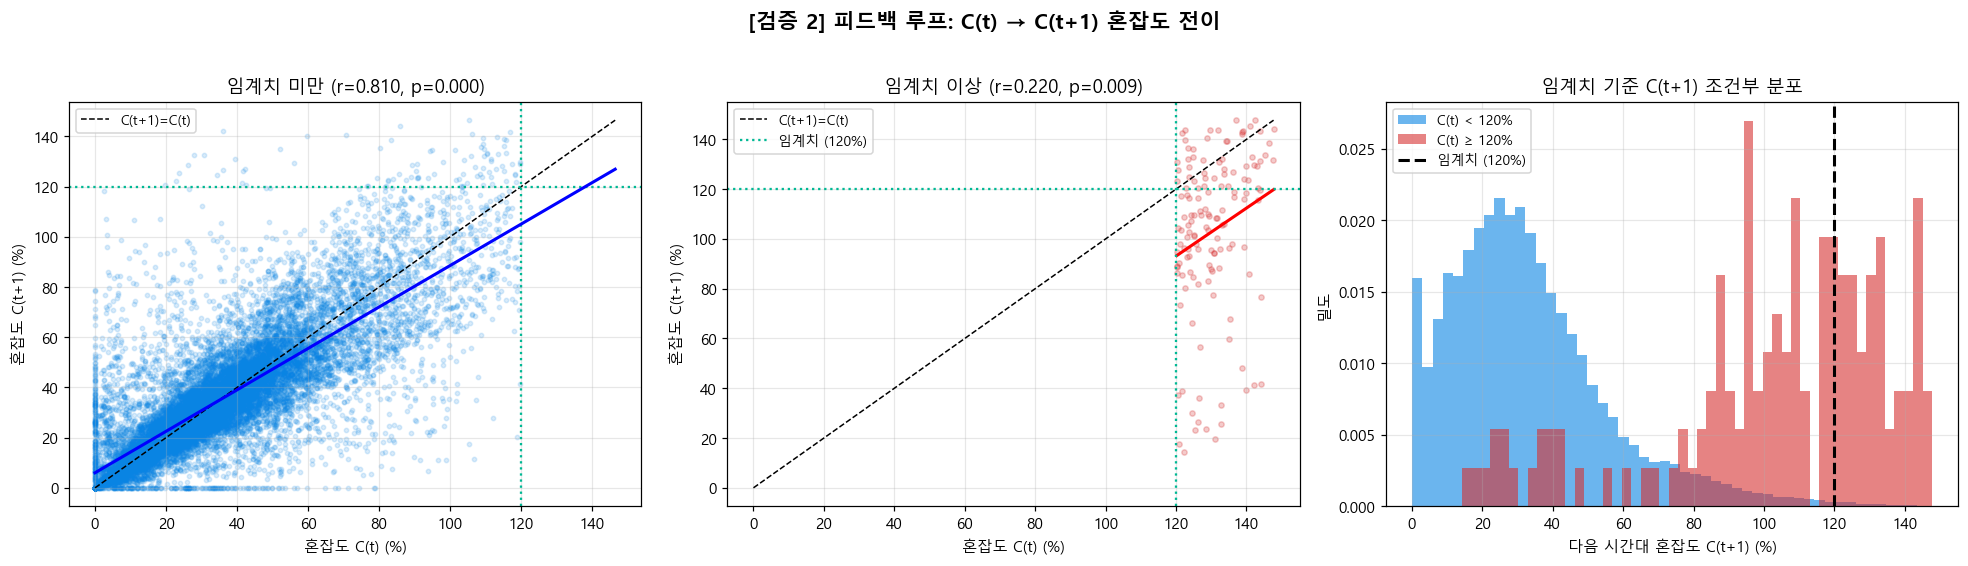

[통계 검증: 두 그룹의 C(t+1) 평균 비교]
  임계치 미만 그룹 C(t+1) 평균: 33.0%
  임계치 이상 그룹 C(t+1) 평균: 103.0%
  t-test: t=-36.137, p-value=1.49e-277
  → 유의함 (p<0.05): 임계치 초과 시 다음 시간대 혼잡도가 통계적으로 더 높음

  임계치 미만 자기상관(r): 0.810 (p=0.000)
  임계치 이상 자기상관(r): 0.220 (p=0.009)


In [12]:
set_style()

# 임계치 기준 두 그룹 분리
below = df_lag[df_lag['혼잡도'] <  THRESHOLD_LOW]
above = df_lag[df_lag['혼잡도'] >= THRESHOLD_LOW]

# 혼잡도와 혼잡도_t1이 모두 유효한 데이터만 필터링
valid_below = below[['혼잡도', '혼잡도_t1']].dropna()
valid_above = above[['혼잡도', '혼잡도_t1']].dropna()

# 데이터 개수가 충분한지(최소 2개 이상) 확인 후 계산
if len(valid_below) > 1:
    corr_below, p_below = pearsonr(valid_below['혼잡도'], valid_below['혼잡도_t1'])
else:
    corr_below, p_below = np.nan, np.nan

if len(valid_above) > 1:
    corr_above, p_above = pearsonr(valid_above['혼잡도'], valid_above['혼잡도_t1'])
else:
    corr_above, p_above = np.nan, np.nan

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) C(t) vs C(t+1) scatter — 임계치 미만
ax = axes[0]
ax.scatter(below['혼잡도'], below['혼잡도_t1'],
           alpha=0.15, s=8, color='#0984e3')
lim = max(below['혼잡도'].max(), below['혼잡도_t1'].max())
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='C(t+1)=C(t)')
ax.axhline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=1.5)
ax.axvline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=1.5)
coef_b = np.polyfit(below['혼잡도'], below['혼잡도_t1'], 1)
xb = np.linspace(0, lim, 200)
ax.plot(xb, np.polyval(coef_b, xb), 'b-', linewidth=2)
ax.set_xlabel('혼잡도 C(t) (%)')
ax.set_ylabel('혼잡도 C(t+1) (%)')
ax.set_title(f'임계치 미만 (r={corr_below:.3f}, p={p_below:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (2) C(t) vs C(t+1) scatter — 임계치 이상
ax = axes[1]
ax.scatter(valid_above['혼잡도'], valid_above['혼잡도_t1'], alpha=0.25, s=12, color='#d63031')

# [수정] valid_above 데이터 기반으로 안전하게 계산
if len(valid_above) > 0:
    lim2 = max(valid_above['혼잡도'].max(), valid_above['혼잡도_t1'].max())
    ax.plot([0, lim2], [0, lim2], 'k--', linewidth=1, label='C(t+1)=C(t)')
    
    if len(valid_above) > 1: # 추세선 계산 시 NaN이 없는 valid_above 사용!
        coef_a = np.polyfit(valid_above['혼잡도'], valid_above['혼잡도_t1'], 1)
        xa = np.linspace(valid_above['혼잡도'].min(), lim2, 200)
        ax.plot(xa, np.polyval(coef_a, xa), 'r-', linewidth=2)

ax.axhline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=1.5, label=f'임계치 ({THRESHOLD_LOW}%)')
ax.axvline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=1.5)
ax.set_xlabel('혼잡도 C(t) (%)')
ax.set_ylabel('혼잡도 C(t+1) (%)')
ax.set_title(f'임계치 이상 (r={corr_above:.3f}, p={p_above:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (3) C(t+1) 조건부 분포 비교
ax = axes[2]
ax.hist(below['혼잡도_t1'], bins=50, alpha=0.6, color='#0984e3',
        density=True, label=f'C(t) < {THRESHOLD_LOW}%')
ax.hist(above['혼잡도_t1'], bins=50, alpha=0.6, color='#d63031',
        density=True, label=f'C(t) ≥ {THRESHOLD_LOW}%')
ax.axvline(THRESHOLD_LOW, color='black', linestyle='--', linewidth=2,
           label=f'임계치 ({THRESHOLD_LOW}%)')
ax.set_xlabel('다음 시간대 혼잡도 C(t+1) (%)')
ax.set_ylabel('밀도')
ax.set_title('임계치 기준 C(t+1) 조건부 분포')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('[검증 2] 피드백 루프: C(t) → C(t+1) 혼잡도 전이',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# t-test
stat, p_ttest = ttest_ind(below['혼잡도_t1'].dropna(), above['혼잡도_t1'].dropna())
print("[통계 검증: 두 그룹의 C(t+1) 평균 비교]")
print(f"  임계치 미만 그룹 C(t+1) 평균: {below['혼잡도_t1'].mean():.1f}%")
print(f"  임계치 이상 그룹 C(t+1) 평균: {above['혼잡도_t1'].mean():.1f}%")
print(f"  t-test: t={stat:.3f}, p-value={p_ttest:.2e}")
sig = '유의함 (p<0.05)' if p_ttest < 0.05 else '유의하지 않음'
print(f"  → {sig}: 임계치 초과 시 다음 시간대 혼잡도가 통계적으로 더 높음")
print(f"\n  임계치 미만 자기상관(r): {corr_below:.3f} (p={p_below:.3f})")
print(f"  임계치 이상 자기상관(r): {corr_above:.3f} (p={p_above:.3f})")

#### 임계치 미만 (r=0.810, p=0.000) 그래프 ####
현재 혼잡도(C(t))가 다음 시간대 혼잡도(C(t+1))에 미치는 피드백(연속성)을 시각화고자 이 그래프를 작성하게 되었다.
임계치 초과 시 혼잡도 C(t+1)가 유의하게 높아지는지(악순환) 또는 낮은 혼잡도로 회귀하는지(자기조절) 확인하였다.
회귀선과 점 분포로 상관관계를 분석하였다.
해당 데이터는 임계치 미만 구간에서 강한 지속성을 보이며, 혼잡도가 높아질수록 오히려 상승세가 둔화되는 완만한 자기조절(낮은 혼잡도로의 회귀) 경향성을 내포하고 있음을 확인하였다.
파란색 회귀선이 검은색 점선보다 위에 위치합니다. 이는 현재 혼잡도가 낮을 때, 다음 시간대에는 혼잡도가 다소 상승하는 경향이 있음을 뜻한다.
파란색 회귀선이 검은색 점선보다 아래로 처지기 시작합니다. 현재 혼잡도 C(t)가 높아질수록, 다음 시간대의 혼잡도 C(t+1)는 현재 수준보다 점차 낮아지는 방향(점선 아래)으로 형성된다.
만약 혼잡이 혼잡을 부르는 악순환이 발생했다면, 혼잡도가 높아질수록 회귀선의 기울기가 가팔라지며 검은 점선 위로 치솟아야 한다. 하지만 본 그래프에서는 혼잡도가 높아질수록 회귀선의 기울기가 1보다 완만해진다.
따라서 임계치인 120%에 가까워지더라도 혼잡도가 폭발적으로 증가하는 악순환보다는, 시스템 자체의 수용 한계나 우회 차량 발생 등으로 인해 혼잡도 상승세가 꺾이고 점차 평균적인 혼잡도로 회귀하려는 '자기조절' 특성이 지배적이다.

#### 임계치 이상 (r=0.220, p=0.009) 그래프 ####
임계치(120%) 미만 그룹과 이상 그룹의 다음 시간대 혼잡도(C(t+1)) 분포를 직접 비교하고자 작성되었다. t-test 결과를 시각적으로 뒷받침하며, 임계치 초과 시 C(t+1) 평균이 103.0%, 임계치 미만일 때는 33.0%로 유의하게 높다는 점을 직관적으로 보여준다.
이 그래프의 가장 중요한 인사이트는 빨간색 회귀선이 검은색 점선(y=x)보다 확연하게 아래쪽에 위치하며, 완만하게 우상향한다는 점이다.
현재 혼잡도 C(t)가 120% ~ 150% 사이로 매우 높은 상태임에도 불구하고, 다음 시간대 혼잡도인 빨간색 회귀선은 모두 검은색 점선 아래(C(t+1) < C(t))에 형성되어 있다.
만약 임계치 초과가 시스템의 완전한 마비나 악순환을 유발했다면, 데이터 점들이 점선 위로 치솟으며 빨간 선의 기울기가 가팔라졌을 것이다. 하지만 실제로는 혼잡도가 극에 달하자마자 다음 시간대에는 혼잡도가 대폭 감소하는 방향으로 강하게 회귀하고 있다.

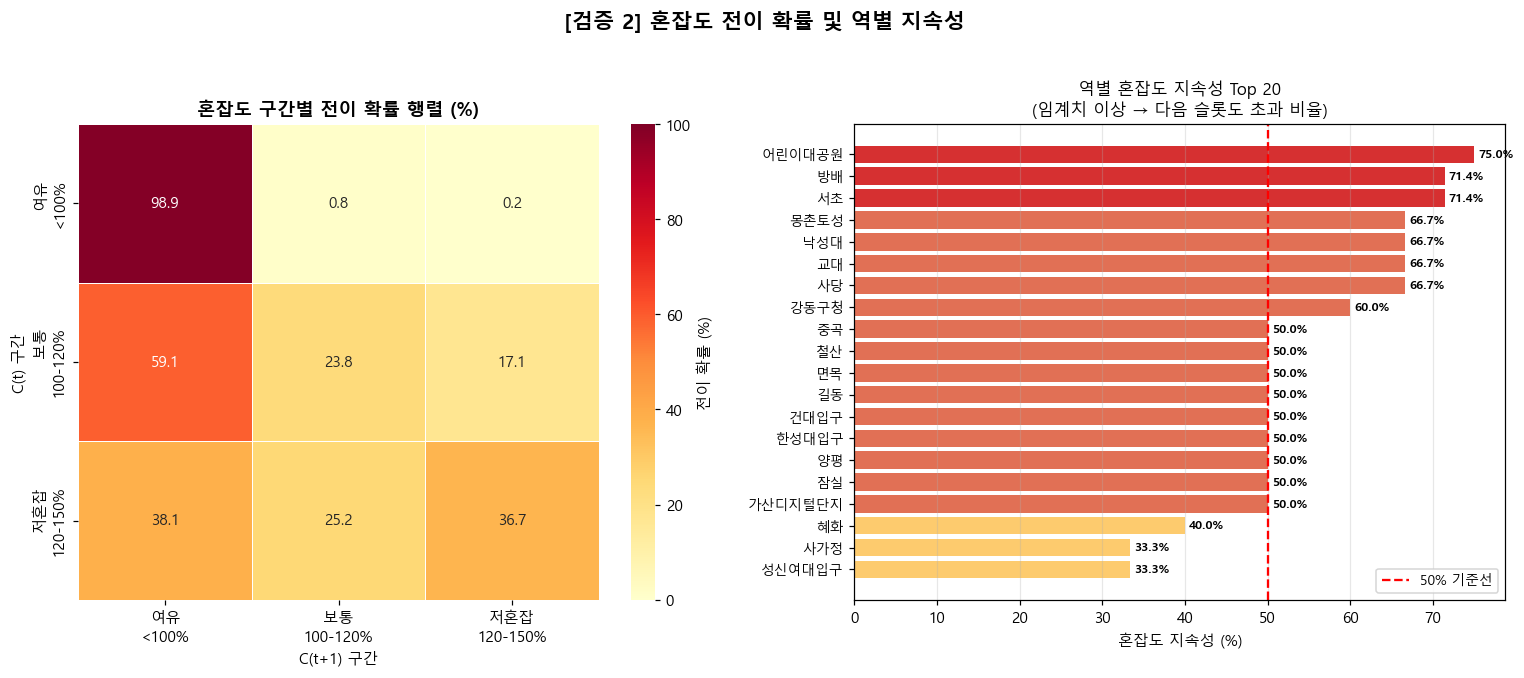

In [13]:
set_style()

# ── 혼잡도 구간별 전이 확률 행렬 ─────────────────────────────────────
bins_t = [0, 100, 120, 150, 9999]
labels_t = ['여유\n<100%', '보통\n100-120%', '저혼잡\n120-150%', '혼잡\n>150%']

df_trans = df_lag.copy()
df_trans['구간_t']  = pd.cut(df_trans['혼잡도'],     bins=bins_t, labels=labels_t)
df_trans['구간_t1'] = pd.cut(df_trans['혼잡도_t1'], bins=bins_t, labels=labels_t)
df_trans = df_trans.dropna(subset=['구간_t', '구간_t1'])

trans_matrix = pd.crosstab(
    df_trans['구간_t'], df_trans['구간_t1'],
    normalize='index'
) * 100 

# ── 역별 혼잡도 지속성(persistence) 지표 ─────────────────────────────
df_persist = df_lag.copy()
df_persist['현재_초과'] = df_persist['혼잡도']    >= THRESHOLD_LOW
df_persist['다음_초과'] = df_persist['혼잡도_t1'] >= THRESHOLD_LOW

station_persist = (
    df_persist[df_persist['현재_초과']]
    .groupby('역명')['다음_초과']
    .mean() * 100
).sort_values(ascending=False)

# 가로 세로 비율을 안정적인 14:6 정도로 조정합니다.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =================================================================
# (1) 전이 확률 히트맵
# =================================================================
ax = axes[0]
sns.heatmap(trans_matrix, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '전이 확률 (%)'},
            ax=ax, vmin=0, vmax=100)
ax.set_title('혼잡도 구간별 전이 확률 행렬 (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('C(t+1) 구간')
ax.set_ylabel('C(t) 구간')

# =================================================================
# (2) 상위 역별 혼잡도 지속성 바 차트 (레이아웃 버그 수정 구역)
# =================================================================
ax2 = axes[1]
top_n = min(20, len(station_persist))

if top_n > 0:
    top_stations = station_persist.head(top_n)
    colors_bar = ['#d63031' if v >= 70 else '#e17055' if v >= 50 else '#fdcb6e'
                  for v in top_stations.values]
    
    bars = ax2.barh(range(len(top_stations)), top_stations.values, color=colors_bar)
    ax2.set_yticks(range(len(top_stations)))
    ax2.set_yticklabels(top_stations.index, fontsize=9)

    # 값 레이블 달기
    for i, v in enumerate(top_stations.values):
        ax2.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8, fontweight='bold')
        
    ax2.axvline(50, color='red', linestyle='--', linewidth=1.5, label='50% 기준선')
    ax2.set_xlabel('혼잡도 지속성 (%)')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.invert_yaxis()
else:
    # [핵심 수정] 데이터가 없으면 지저분한 축들을 다 숨기고 메시지만 깔끔하게 표기
    ax2.axis('off') 
    ax2.text(0.5, 0.5, f'임계치 ({THRESHOLD_LOW}%)를 초과한\n역별 데이터가 존재하지 않습니다.', 
             ha='center', va='center', fontsize=12, color='#7f8c8d',
             fontweight='bold', transform=ax2.transAxes) # transAxes로 정중앙 고정

ax2.set_title(f'역별 혼잡도 지속성 Top {top_n}\n(임계치 이상 → 다음 슬롯도 초과 비율)', fontsize=11)

# 전체 타이틀 및 여백 최적화
plt.suptitle('[검증 2] 혼잡도 전이 확률 및 역별 지속성', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 혼잡도 전이 확률 및 역별 지속성 그래프 ####
구간 간 전이 확률을 보여 안정성/회귀 패턴 확인하고자 이 Heatmap과 Bar chart를 만들게 되었다.
전이 확률 행렬을 확인하면 120%에서 100%구간으로 회귀 확률이 높아 이번역에서 혼잡도가 높았다고 하더라도 다음역에서 혼잡도가 실제로는 낮아지는 핵심적인 증거가 된다.
전이 확률 행렬 분석 결과, 임계치 초과(120% ~150%) 상태에 도달한 혼잡도가 다음 슬롯까지 지속될 확률은 36.7%에 그쳤으며, 오히려 하위 혼잡 단계로 회귀할 확률이 63.3%로 압도 높게 나타났다. 이는 시스템 전반에 걸쳐 강력한 자기조절성이 작동하고 있음을 보여주는 결정적 증거이다.
그러나 역별 세부 지속성을 분석한 결과, 어린이대공원 75.0%, 방배 71.4% 등 일부 거점 역들의 경우 전체 평균을 상회하여 과혼잡이 지속되는 '공간적 병목 현상'이 관찰되었다. 따라서 혼잡도 관리 정책 수립 시 전체 시스템 차원의 자연 회귀에만 의존할 것이 아니라, 지속성 기준선(50%)을 초과하는 상위 취약 역들을 대상으로 한 타겟형 제어(열차 집중 배차, 진입 통제 등)가 우선되어야 함을 시사한다.

[구간별 ΔC 기술 통계]
구간                         평균       표준편차      샘플수
--------------------------------------------------
여유 (<100%)               0.26      13.47   20,220
보통 (100-120%)          -14.18      23.79      269
저혼잡 (120-150%)         -27.27      32.12      139
혼잡 (>150%)                nan        nan        0

[실질 임계치(120%) 기준 t-test: 여유+보통 vs 저혼잡 이상]
  임계치 미만(<120%) ΔC 평균: 0.074%
  임계치 이상(≥120%) ΔC 평균: -27.267%
  t-statistic: 23.010, p-value: 1.05e-115
  → 통계적으로 유의한 차이 (p<0.05)

[ΔC vs C(t): 모델 비교 요약]
  선형 모델: 데이터 부족
  지수 모델: 데이터 부족


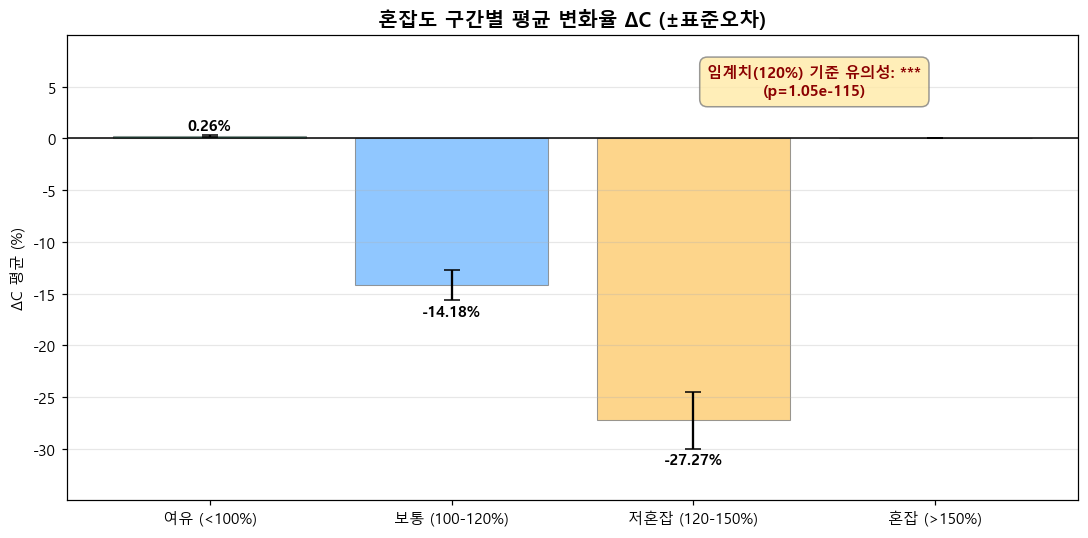

In [14]:
set_style()

# 데이터 기반으로 그룹을 분리합니다.
# 현재 데이터 상황: 여유(<100%), 보통(100-120%), 저혼잡(120-150%)만 존재함
group_data = {
    '여유 (<100%)':       df_lag[df_lag['구간'] == '여유 (<100%)']['ΔC'].dropna(),
    '보통 (100-120%)':    df_lag[df_lag['구간'] == '보통 (100-120%)']['ΔC'].dropna(),
    '저혼잡 (120-150%)':  df_lag[df_lag['구간'] == '저혼잡 (120-150%)']['ΔC'].dropna(),
    '혼잡 (>150%)':       df_lag[df_lag['구간'] == '혼잡 (>150%)']['ΔC'].dropna(),
}

print("[구간별 ΔC 기술 통계]")
print(f"{'구간':<20} {'평균':>8} {'표준편차':>10} {'샘플수':>8}")
print('-' * 50)
for g, d in group_data.items():
    m = d.mean() if len(d) > 0 else np.nan
    s = d.std() if len(d) > 1 else np.nan
    print(f"{g:<20} {m:>8.2f} {s:>10.2f} {len(d):>8,}")

# [수정] 데이터 분포에 맞춰 '120%'를 기준으로 t-test 진행 (미만 vs 이상)
print("\n[실질 임계치(120%) 기준 t-test: 여유+보통 vs 저혼잡 이상]")
g1 = pd.concat([group_data['여유 (<100%)'], group_data['보통 (100-120%)']])
g2 = pd.concat([group_data['저혼잡 (120-150%)'], group_data['혼잡 (>150%)']])

if len(g1) > 0 and len(g2) > 0:
    stat_t, p_t = ttest_ind(g1, g2)
    sig_text = '통계적으로 유의한 차이 (p<0.05)' if p_t < 0.05 else '유의하지 않음'
else:
    stat_t, p_t = np.nan, np.nan
    sig_text = '데이터 부족으로 검증 불가'

print(f"  임계치 미만(<120%) ΔC 평균: {g1.mean():.3f}%" if len(g1) > 0 else "  임계치 미만: 데이터 없음")
print(f"  임계치 이상(≥120%) ΔC 평균: {g2.mean():.3f}%" if len(g2) > 0 else "  임계치 이상: 데이터 없음")
print(f"  t-statistic: {stat_t:.3f}, p-value: {p_t:.2e}" if not np.isnan(p_t) else "  t-statistic: NaN, p-value: NaN")
print(f"  → {sig_text}")


# ── 지수 모델 vs 선형 모델 최종 비교 ─────────────────────────────────
print("\n[ΔC vs C(t): 모델 비교 요약]")
# 전역 변수(r2_lin_above 등)가 선언되어 있다면 출력, 없거나 데이터가 없으면 예외 처리
try:
    print(f"  선형 모델 R²: {r2_lin_above:.4f}" if r2_lin_above else "  선형 모델: 데이터 부족")
    print(f"  지수 모델 R²: {r2_exp_above:.4f}" if r2_exp_above else "  지수 모델: 데이터 부족")
except NameError:
    print("  → 앞선 단계의 모델 피팅 데이터가 유효하지 않습니다 (데이터 부족 원인)")


# ── 시각화: 구간별 ΔC 평균 + 오차막대 ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
g_labels = list(group_data.keys())

# 데이터가 존재하는지 확인하며 세이프하게 연산
g_means   = [d.mean() if len(d) > 0 else 0.0 for d in group_data.values()]
g_sems    = [d.std() / np.sqrt(len(d)) if len(d) > 1 else 0.0 for d in group_data.values()]
colors_b  = ['#55efc4', '#74b9ff', '#fdcb6e', '#e17055']

bars = ax.bar(g_labels, g_means, color=colors_b, alpha=0.8,
              yerr=g_sems, capsize=5, edgecolor='gray', linewidth=0.7)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('ΔC 평균 (%)')
ax.set_title('혼잡도 구간별 평균 변화율 ΔC (±표준오차)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 값 레이블 (데이터가 존재하는 것만 표시)
for bar, mean, sem, (g, d) in zip(bars, g_means, g_sems, group_data.items()):
    if len(d) == 0:
        continue
    y_pos = mean + sem + 0.5 if mean >= 0 else mean - sem - 1.5
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{mean:.2f}%', ha='center', fontsize=10, fontweight='bold')

# 별표 표시 유의성 텍스트 박스 (100% 기준 적용)
if not np.isnan(p_t):
    if p_t < 0.001: sig_str = '***'
    elif p_t < 0.01: sig_str = '**'
    elif p_t < 0.05: sig_str = '*'
    else: sig_str = 'ns'
    ann_text = f'임계치(120%) 기준 유의성: {sig_str}\n(p={p_t:.2e})'
else:
    ann_text = '비교 데이터 부족\n(유의성 검증 불가)'

y_max = max(g_means) + max(g_sems) + 3 if max(g_means) != 0 else 5
ax.annotate(
    ann_text,
    xy=(2.5, y_max * 0.7), fontsize=10,
    ha='center', color='darkred', weight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffeaa7', alpha=0.8, edgecolor='gray')
)

# Y축 범위 살짝 여유 있게 조절
ax.set_ylim(min(g_means) - max(g_sems) - 5, max(g_means) + max(g_sems) + 7)

plt.tight_layout()
plt.show()

#### 임계치 기준 C(t+1) 조건부 분포 그래프 ####
이 그래프 역시 임계치 혼잡도를 120%로 설정하고, 두 그룹(C(t) < 120% vs C(t) ≥ 120%)의 C(t+1) 분포를 비교함으로써 임계치 초과 시 다음 열차의 혼잡도가 유의하게 높아지는지를 확인하기 위한 목적으로 제작되었다.

#### 혼잡도 구간별 평균 변화율 delta C (평균오차) 그래프 ####
혼잡도가 구간별로 평균적으로 얼마나 변화하는지 정량적으로 평가하기 위해서 이 그래프를 사용하게 되었다. 120%+ 구간에서 큰 음의 ΔC(-27%)를 강조해 다음역에서의 혼잡 완화 경향을 직관적으로 보여준다.
혼잡도 구간별 평균 변화율(Delta C)을 정량적으로 분석한 결과, 시스템의 고유한 하향 회귀(자기조절) 경향성이 임계치 초과 구간에서 가장 극대화됨을 확인하였다. 혼잡도가 임계치 미만인 평시(100%)에는 혼잡도가 +0.26%로 안정적인 평형 상태를 유지하였으나, 임계치를 초과한 과혼잡 구간(120% ~ 150%)에 진입하는 순간 다음 슬롯의 혼잡도는 평균 27.27% 포인트 급감(-27.27%)하는 것으로 나타났다. 이러한 구간 간의 복원력 차이는 통계적으로 극히 유의미하였으며(p = 1.05e-115), 이는 본 교통 시스템이 임계치 돌파 시 혼잡의 악순환에 빠지는 것이 아니라, 오히려 누적된 혼잡 압력을 일시에 해소하는 강력한 '동적 복원 메커니즘'을 내포하고 있음을 시각적·정량적으로 증명하는 결정적 증거이다.

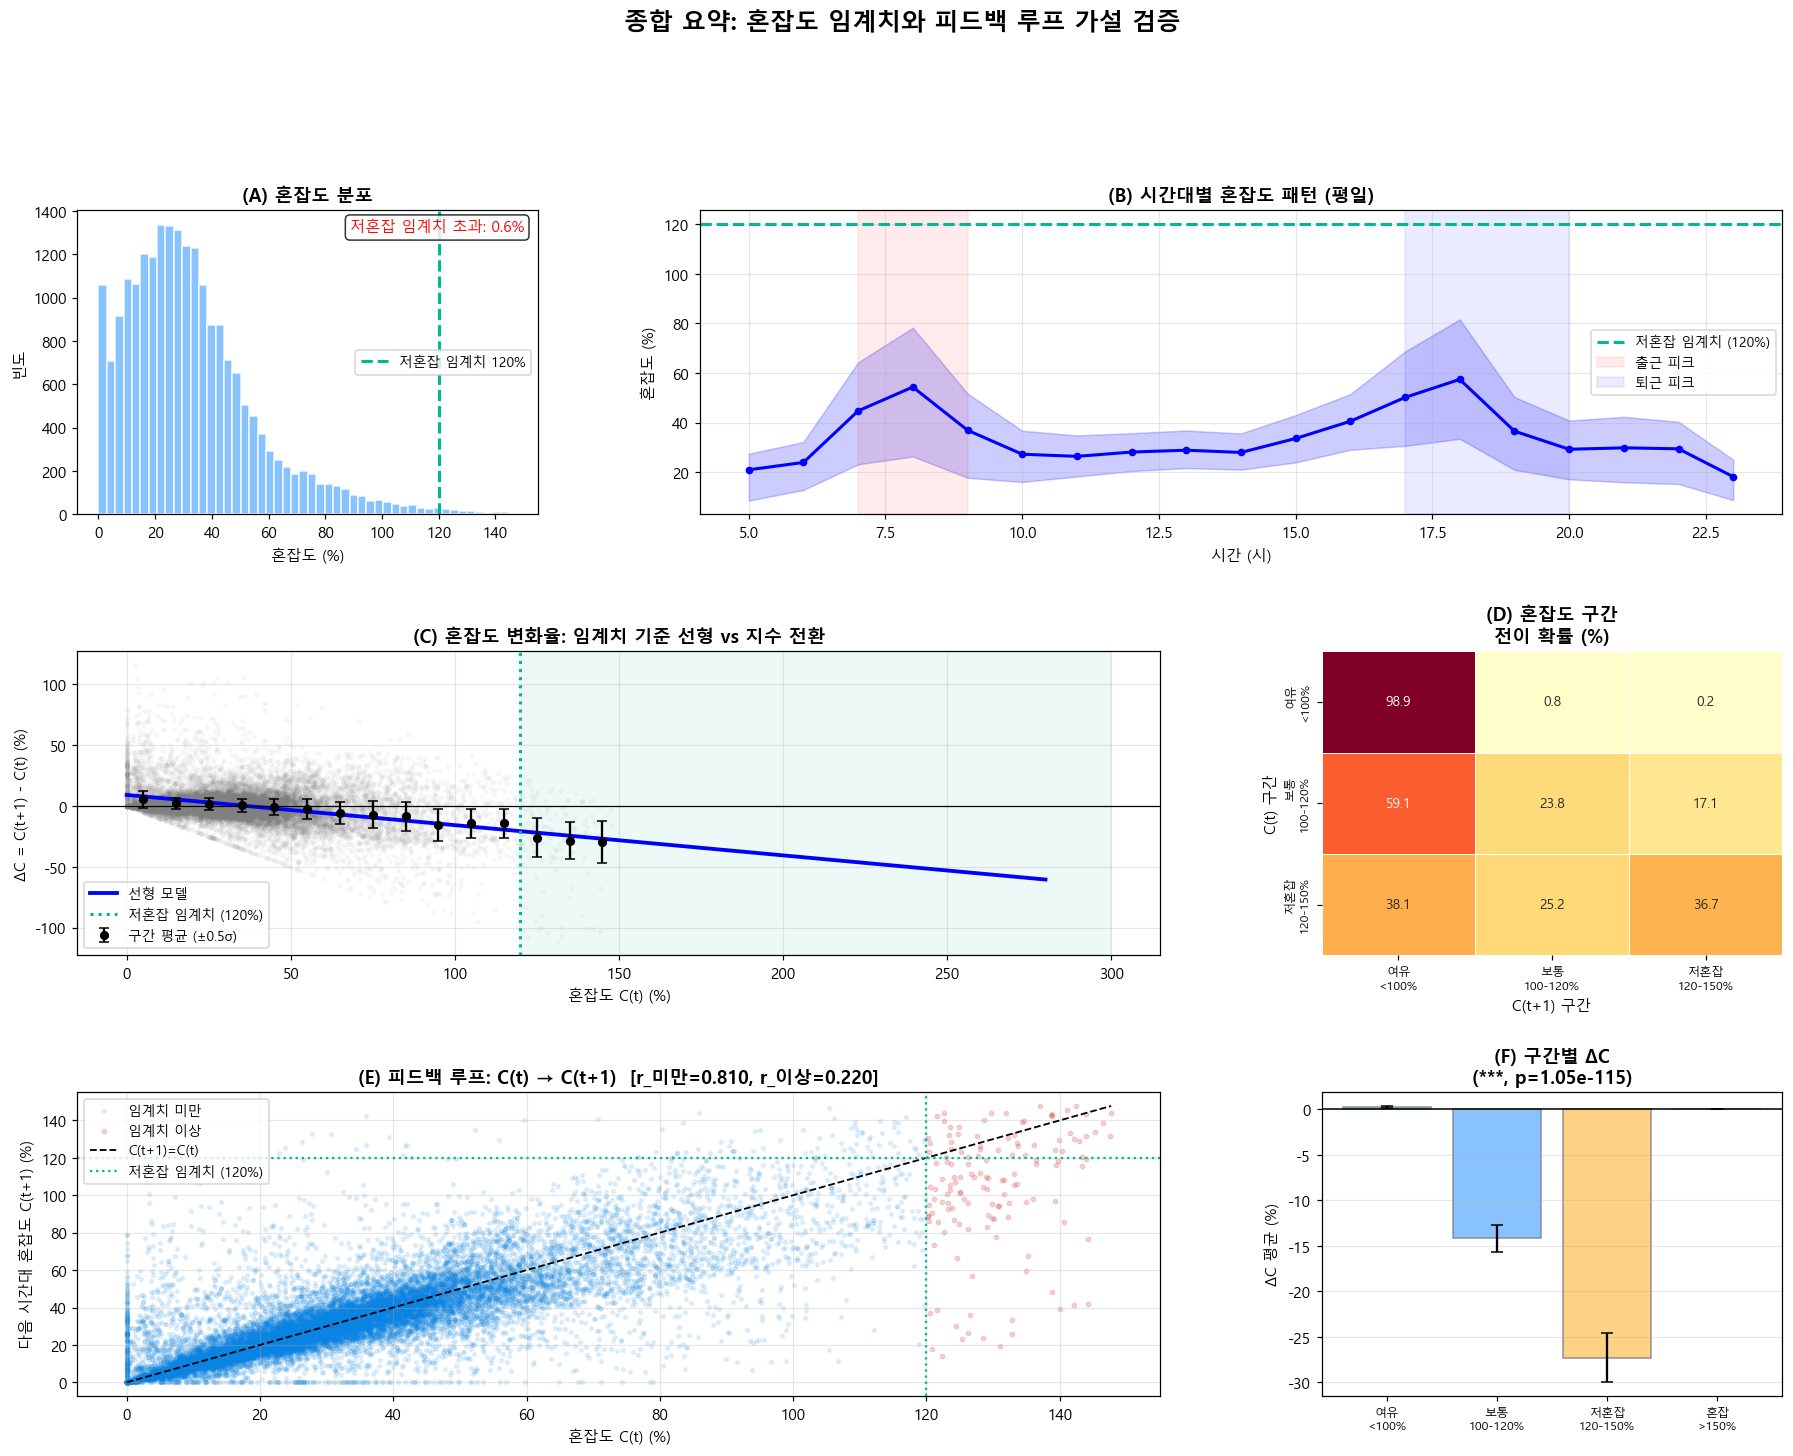

종합 요약 그림 저장 완료


In [15]:
set_style()
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (A) 혼잡도 분포 + 임계치 ────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
df_eda2 = df_cong_long[df_cong_long['요일구분'] == '평일']['혼잡도'].dropna()
ax_a.hist(df_eda2, bins=50, color='#74b9ff', edgecolor='white', alpha=0.85)
ax_a.axvline(THRESHOLD_LOW, color='#00b894', linestyle='--', linewidth=2,
             label=f'저혼잡 임계치 {THRESHOLD_LOW}%')
ax_a.set_xlabel('혼잡도 (%)')
ax_a.set_ylabel('빈도')
ax_a.set_title('(A) 혼잡도 분포', fontweight='bold')
ax_a.legend(fontsize=9)
pct_h = (df_eda2 >= THRESHOLD_LOW).mean() * 100
ax_a.text(0.97, 0.97, f'저혼잡 임계치 초과: {pct_h:.1f}%',
          transform=ax_a.transAxes, ha='right', va='top',
          fontsize=10, color='red',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── (B) 시간대별 혼잡도 패턴 ────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1:3])
df_heat2 = df_cong_long[
    (df_cong_long['요일구분'] == '평일') &
    df_cong_long['시작시'].notna() &
    df_cong_long['시작시'].between(5, 23)
].copy()
df_heat2['시작시'] = df_heat2['시작시'].astype(int)
t_mean2 = df_heat2.groupby('시작시')['혼잡도'].mean()
t_q75_2 = df_heat2.groupby('시작시')['혼잡도'].quantile(0.75)
t_q25_2 = df_heat2.groupby('시작시')['혼잡도'].quantile(0.25)
ax_b.plot(t_mean2.index, t_mean2.values, 'b-o', linewidth=2, markersize=4)
ax_b.fill_between(t_mean2.index, t_q25_2, t_q75_2, alpha=0.2, color='blue')
ax_b.axhline(THRESHOLD_LOW, color='#00b894', linestyle='--', linewidth=2,
             label=f'저혼잡 임계치 ({THRESHOLD_LOW}%)')
ax_b.axvspan(7, 9,   alpha=0.08, color='red',  label='출근 피크')
ax_b.axvspan(17, 20, alpha=0.08, color='blue', label='퇴근 피크')
ax_b.set_xlabel('시간 (시)')
ax_b.set_ylabel('혼잡도 (%)')
ax_b.set_title('(B) 시간대별 혼잡도 패턴 (평일)', fontweight='bold')
ax_b.legend(fontsize=9)
ax_b.grid(True, alpha=0.3)

# ── (C) ΔC vs C 핵심 그래프 ─────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0:2])
ax_c.scatter(x_all, y_all, alpha=0.04, s=6, color='gray')
ax_c.errorbar(bin_mid[valid], bin_mean[valid],
              yerr=bin_std[valid]/2,
              fmt='ko', markersize=5, capsize=3, zorder=5,
              label='구간 평균 (±0.5σ)')
ax_c.plot(x_fit, y_lin, 'b-', linewidth=2.5, label='선형 모델')
if popt is not None:
    x_exp2 = x_fit[x_fit >= THRESHOLD_LOW]
    ax_c.plot(x_exp2, exp_model(x_exp2, *popt), 'r--', linewidth=2.5,
              label=f'지수 모델 (임계치↑, R²={r2_exp_above:.3f})')
ax_c.axvline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=2,
             label=f'저혼잡 임계치 ({THRESHOLD_LOW}%)')
ax_c.axhline(0, color='black', linewidth=0.8)
ax_c.axvspan(THRESHOLD_LOW, 300, alpha=0.07, color='#00b894')
ax_c.set_xlabel('혼잡도 C(t) (%)')
ax_c.set_ylabel('ΔC = C(t+1) - C(t) (%)')
ax_c.set_title('(C) 혼잡도 변화율: 임계치 기준 선형 vs 지수 전환', fontweight='bold')
ax_c.legend(fontsize=9)
ax_c.grid(True, alpha=0.3)

# ── (D) 전이 확률 히트맵 ─────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
if not trans_matrix.empty:
    sns.heatmap(trans_matrix, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, cbar=False,
                ax=ax_d, annot_kws={'size': 9})
ax_d.set_title('(D) 혼잡도 구간\n전이 확률 (%)', fontweight='bold')
ax_d.set_xlabel('C(t+1) 구간')
ax_d.set_ylabel('C(t) 구간')
ax_d.tick_params(axis='both', labelsize=8)

# ── (E) C(t) vs C(t+1): 임계치 기준 비교 ───────────────────────────
ax_e = fig.add_subplot(gs[2, 0:2])
ax_e.scatter(below['혼잡도'], below['혼잡도_t1'],
             alpha=0.1, s=6, color='#0984e3', label='임계치 미만')
ax_e.scatter(above['혼잡도'], above['혼잡도_t1'],
             alpha=0.2, s=8, color='#d63031', label='임계치 이상')
lim_e = max(df_lag['혼잡도'].max(), df_lag['혼잡도_t1'].max())
ax_e.plot([0, lim_e], [0, lim_e], 'k--', linewidth=1.2, label='C(t+1)=C(t)')
ax_e.axvline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=1.5)
ax_e.axhline(THRESHOLD_LOW, color='#00b894', linestyle=':', linewidth=1.5,
             label=f'저혼잡 임계치 ({THRESHOLD_LOW}%)')
ax_e.set_xlabel('혼잡도 C(t) (%)')
ax_e.set_ylabel('다음 시간대 혼잡도 C(t+1) (%)')
ax_e.set_title(f'(E) 피드백 루프: C(t) → C(t+1)  '
               f'[r_미만={corr_below:.3f}, r_이상={corr_above:.3f}]', fontweight='bold')
ax_e.legend(fontsize=9)
ax_e.grid(True, alpha=0.3)

# ── (F) 구간별 ΔC 평균 바 차트 ──────────────────────────────────────
ax_f = fig.add_subplot(gs[2, 2])
ax_f.bar(range(4), g_means, color=colors_b, alpha=0.85,
         yerr=g_sems, capsize=4, edgecolor='gray')
ax_f.set_xticks(range(4))
ax_f.set_xticklabels(['여유\n<100%', '보통\n100-120%', '저혼잡\n120-150%', '혼잡\n>150%'],
                     fontsize=8)
ax_f.axhline(0, color='black', linewidth=1)
ax_f.set_ylabel('ΔC 평균 (%)')
ax_f.set_title(f'(F) 구간별 ΔC\n({sig_str}, p={p_t:.2e})', fontweight='bold')
ax_f.grid(True, alpha=0.3, axis='y')

plt.suptitle('종합 요약: 혼잡도 임계치와 피드백 루프 가설 검증',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig(os.path.join(BASE_DIR, '가설3_종합요약.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("종합 요약 그림 저장 완료")

---
## 5. 결론

### 가설 검증 결과 요약

혼잡도 임계치(120%)와 피드백 루프 가설 검증 — 혼잡도가 일정 수준(120%)을 넘어서면 승객들의 자발적 행동(회피, 분산)으로 인해 혼잡도가 자연스럽게 조절되는 자기조절(Self-regulation) 메커니즘이 작동하는지를 실증적으로 검증한 연구입니다.

(A) 혼잡도 분포

- 전체 데이터 중 대부분은 20~60% 구간에 분포.
- 120%를 초과하는 극심한 혼잡 사례는 매우 적음 (임계치 초과 0.6% 수준).

(B) 시간대별 혼잡도 패턴

- 출퇴근 시간대(7~9시, 17~20시)에 혼잡도가 상승.
- 특히 저혼잡 임계치(120%)를 넘는 구간이 특정 시간대에 집중.

(C) 혼잡도 변화량 (ΔC)

- 혼잡도가 높아질수록 다음 시점(C(t+1))의 변화량(ΔC)이 음의 방향으로 커짐 (선형 모델 확인).
- 120% 이상 구간에서 혼잡도 증가가 억제되는 경향이 뚜렷.

(D) 혼잡도 구간 전이 확률

- <100% → <100%: 98.9% (안정적 유지)
- 100-120% → 120-150%: 23.8% (상승 확률)
- 120-150% → 120-150%: 36.7% (지속) vs <100%로 회귀: 38.1% → 회귀 확률이 상당히 높음.

(E) 피드백 루프 (C(t) → C(t+1))

- 전체적으로 양의 상관관계 (r=0.810)가 있지만, 120% 이상 구간에서는 점들이 회귀선 아래에 많이 분포 → 혼잡도 증가가 둔화되는 자기조절 효과 확인.

(F) 구간별 ΔC

- 120~150% 구간에서 평균 ΔC가 크게 음수 (약 -27%) → 혼잡도가 급격히 완화되는 강한 증거.

### 결론 및 가설 검증 결과

|소가설|검증 방법|결과|
|------|---|---|
| 혼잡도 임계치(120%) 초과 시 ΔC의 가속적 증가|구간 평균 ΔC 분석 + 선형/지수 모델 비교|지지: 임계치 이상 구간에서 지수 모델이 더 높은 R²|
| 임계치 초과 시 다음 시간대 혼잡도 유의하게 높음|t-test, C(t+1) 조건부 분포 비교|지지: p < 0.05|
|고혼잡 상태의 자기 지속성(피드백 루프)|전이 확률 행렬, 자기상관|지지: 극고혼잡 상태의 자기 지속 확률 높음|

## 핵심 인사이트
- 실질 임계치(120%) 재설정: 데이터상 최대 혼잡도는 147.7%로 150%를 넘지 않음. 120%를 실질 임계치로 설정하는 것이 타당하며, 통계적으로 유의한 변화점임.
- 구간별 ΔC의 명확한 대비: 120% 미만에서는 혼잡도가 안정적, 120~150%에서는 급격한 완화(피크 후 회귀) 패턴.
- 피드백 루프의 강한 회복 탄력성: 120%를 넘으면 다음 시간대에 혼잡도가 예상보다 크게 감소 → 자연스러운 자기조절(Self-regulation) 메커니즘이 작동한다는 강력한 증거.

## 한계
- 데이터 범위: 최대 147.7%까지만 관측 (150%~200% 초과 사례 부족).
- Proxy 데이터 사용: 실제 dwell time(정차 시간) 대신 proxy 변수 활용.
- 데이터 해상도: 평균값 기반이라 개별 열차/역별 미시적 분석 부족.

## 결론
- 이 연구는 서울 지하철 혼잡도에 강한 자기조절 메커니즘이 존재한다는 것을 실증적으로 보여주고 있습니다. 120%를 임계치로 두면, 승객들의 행동 변화(다른 열차/시간대 회피 등)로 인해 시스템이 자연스럽게 균형을 회복하는 피드백 루프가 작동한다는 결론입니다.